In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.integrate import trapezoid
from scipy.stats import linregress

from amocatlas import read
from correlation_trends import geostrophy, filters, analysis, correlation, seasonal, trends

In [2]:
figpath = "../figures/"

## This code is PART 2A of Assigment 2 of the Data Analysis in Physical Oceanography course at UHH SS26

In [3]:
## Read the datasets

# 26N transports: MOC, TRANS_FC, TRANS_EKMAN, TRANS_UMO
transports = read.rapid()

# 26N boundary hydrography for Part 1 (TEMP_/PSAL_ WEST & EAST on PRESSURE)

MOC = transports.MOC
TRANS_FC = transports.TRANS_FC
TRANS_EKMAN = transports.TRANS_EKMAN
TRANS_UMO = transports.TRANS_UMO

# # 26N boundary hydrography for Part 1 (TEMP_/PSAL_ WEST & EAST on PRESSURE)
# ts = read.rapid(file_list=["ts_gridded.nc"], transport_only=False)
# # 26N overturning in density coordinates: MOC_SIGMA0
# mt = read.rapid(file_list=["meridional_transports.nc"], transport_only=False)
# # 47N NOAC overturning (monthly): MOC_SIGMA0
# noac = read.read_47n()

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series



In [4]:
# Characterizing the datasets

MOC_stats = analysis.summary_stats(MOC)
UMO_stats = analysis.summary_stats(TRANS_UMO)
print(f"The mean of the MOC RAPID time series is {MOC_stats["mean"]:.2f} Sv")
print(f"The mean of the UMO RAPID time series is {UMO_stats["mean"]:.2f} Sv")

The mean of the MOC RAPID time series is 16.98 Sv
The mean of the UMO RAPID time series is -18.37 Sv


##PART 1

In [5]:
# deseasonalize the timeseries
MOC_deseasonalized = seasonal.remove_seasonal_cycle(MOC)
UMO_deseasonalized = seasonal.remove_seasonal_cycle(TRANS_UMO)

# calculate the mean seasonal cycle
MOC_climatology = seasonal.seasonal_climatology(MOC)
UMO_climatology = seasonal.seasonal_climatology(TRANS_UMO)

EKMAN_climatology = seasonal.seasonal_climatology(TRANS_EKMAN)
FC_climatology = seasonal.seasonal_climatology(TRANS_FC)

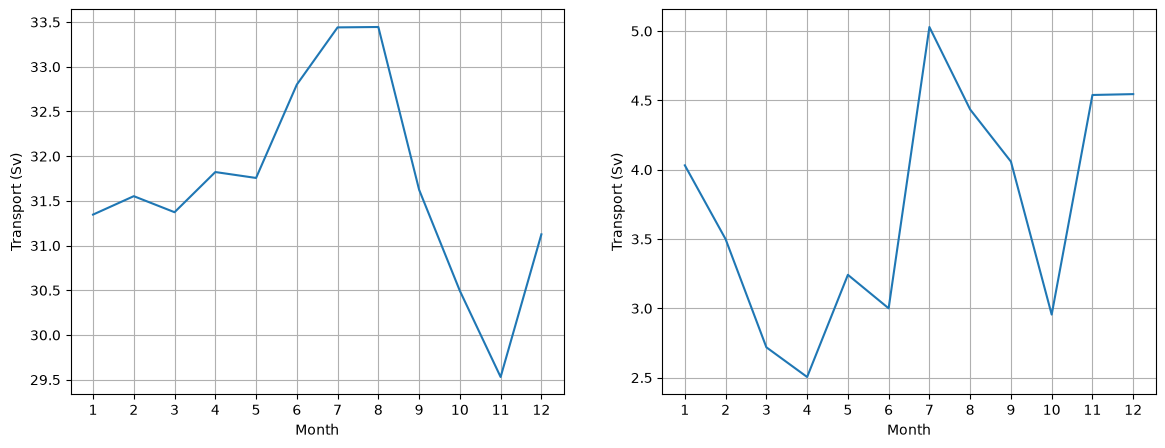

In [6]:
fig, ax = plt.subplots(1,2,figsize=[14,5])
ax[0].plot(np.arange(12)+1,FC_climatology.values)
ax[1].plot(np.arange(12)+1,EKMAN_climatology.values)
for i in [0,1]:
    ax[i].set_xticks(np.arange(12)+1, np.arange(12)+1)
    ax[i].set_xlabel("Month")
    ax[i].set_ylabel("Transport (Sv)")
    ax[i].grid(True)

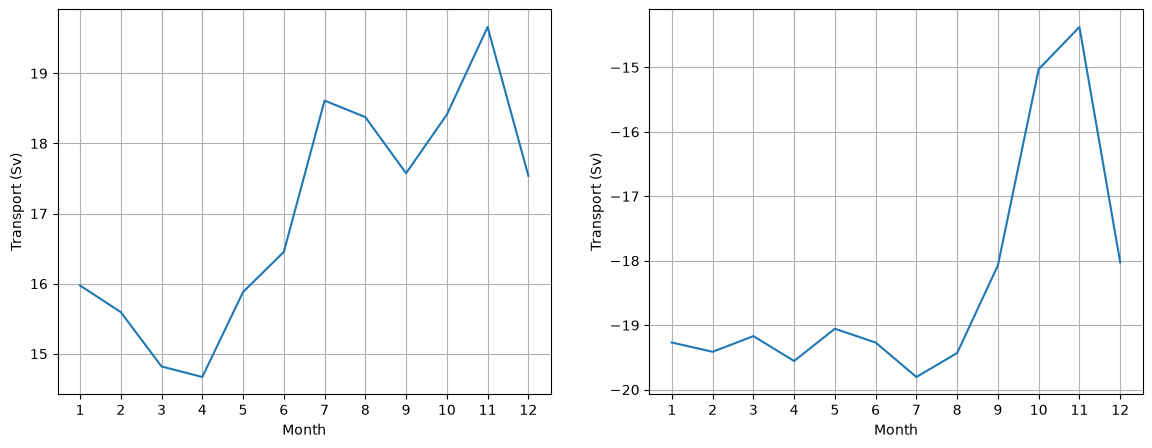

In [7]:
fig, ax = plt.subplots(1,2,figsize=[14,5])
ax[0].plot(np.arange(12)+1,MOC_climatology.values)
ax[1].plot(np.arange(12)+1,UMO_climatology.values)
for i in [0,1]:
    ax[i].set_xticks(np.arange(12)+1, np.arange(12)+1)
    ax[i].set_xlabel("Month")
    ax[i].set_ylabel("Transport (Sv)")
    ax[i].grid(True)

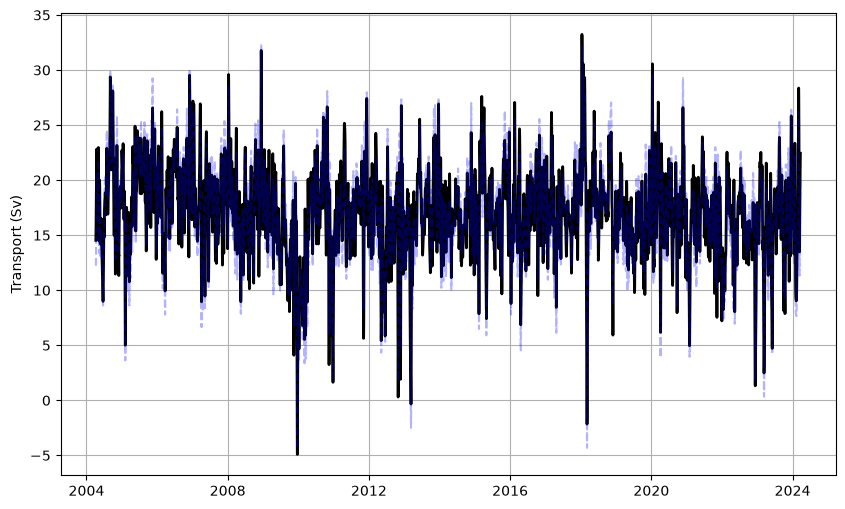

In [8]:
plt.figure(figsize=[10,6])
plt.plot(MOC["TIME"],MOC_deseasonalized, color ="k", lw = 2)
plt.plot(MOC["TIME"],MOC, color = "blue",alpha = 0.3, ls = "--")
#plt.plot(MOC["TIME"][10:3000],filtered_MOC[10:3000], color = "red", alpha = 1, lw = 10)
plt.grid()
plt.ylabel("Transport (Sv)")
plt.savefig(figpath + "seasonal_cycle_comparison.png")

Text(0, 0.5, 'Transport (Sv)')

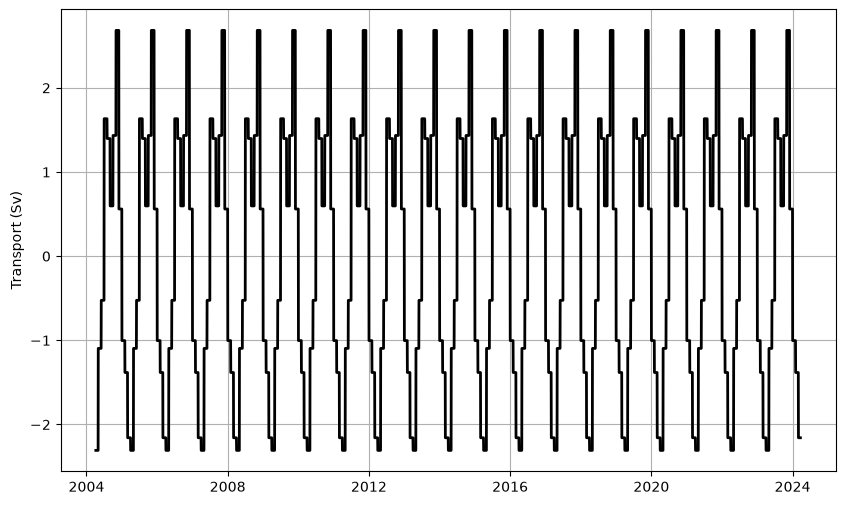

In [9]:
plt.figure(figsize=[10,6])
plt.plot(MOC["TIME"], MOC - MOC_deseasonalized, color ="k", lw = 2)
#plt.plot(MOC["TIME"],MOC, color = "blue",alpha = 0.3, ls = "--")
#plt.plot(MOC["TIME"][10:3000],filtered_MOC[10:3000], color = "red", alpha = 1, lw = 10)
plt.grid()
plt.ylabel("Transport (Sv)")
#plt.savefig(figpath + "seasonal_cycle_comparison.png")

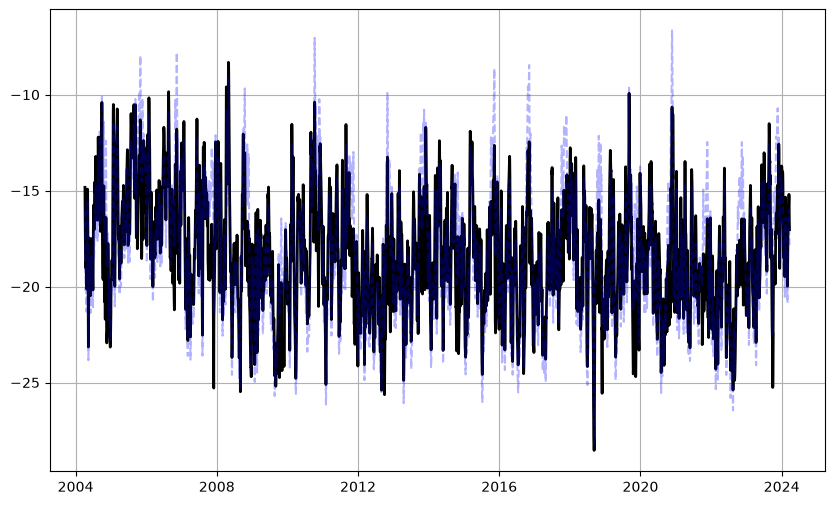

In [10]:
plt.figure(figsize=[10,6])
plt.plot(TRANS_UMO["TIME"],UMO_deseasonalized, color ="k",lw = 2)
plt.plot(TRANS_UMO["TIME"],TRANS_UMO, color = "blue", ls = "--", alpha = 0.3)
plt.grid()

## PART 2A

In [11]:
# detrend the original, not yet deseasonalized time series
MOC_seasonal_detrended = analysis.detrending(MOC, MOC["TIME"].values)
UMO_seasonal_detrended = analysis.detrending(TRANS_UMO,TRANS_UMO["TIME"].values)

# calculate the auto-correlation of the seasonal detrendend time series
ac_MOC_seasonal = correlation.autocorr(MOC_seasonal_detrended, biased = True)
ac_UMO_seasonal = correlation.autocorr(UMO_seasonal_detrended, biased = True)

# calculate the decorrelation timescale (using the integral time scale definition with a cutoff at the first zero crossing)
MOC_decorrelation_timescale = correlation.integral_timescale(MOC_seasonal_detrended, dt = 0.5)
UMO_decorrelation_timescale = correlation.integral_timescale(UMO_seasonal_detrended, dt = 0.5)
print(MOC_decorrelation_timescale)
print(UMO_decorrelation_timescale)

# same as above  but with seasonal cycle removed, not necessary
# MOC_detrended = seasonal.remove_seasonal_cycle(MOC_seasonal_detrended)
# UMO_detrended = seasonal.remove_seasonal_cycle(UMO_seasonal_detrended)
# ac_MOC = correlation.autocorr(MOC_detrended, biased = True)
# ac_UMO = correlation.autocorr(UMO_detrended, biased = True)

# same but with seasonal cycle removed, not necessary
# MOC_detrended = seasonal.remove_seasonal_cycle(MOC_seasonal_detrended)
# UMO_detrended = seasonal.remove_seasonal_cycle(UMO_seasonal_detrended)
# ac_MOC = correlation.autocorr(MOC_detrended, biased = True)
# ac_UMO = correlation.autocorr(UMO_detrended, biased = True)

# MOC_decorrelation_timescale = correlation.integral_timescale(MOC_detrended, dt = 0.5)
# UMO_decorrelation_timescale = correlation.integral_timescale(UMO_detrended, dt = 0.5)
# print(MOC_decorrelation_timescale)
# print(UMO_decorrelation_timescale)


no xarray type, possibly already detrended
no xarray type, possibly already detrended
no xarray type, possibly already detrended
no xarray type, possibly already detrended
18.511922864244802
22.51603193162272


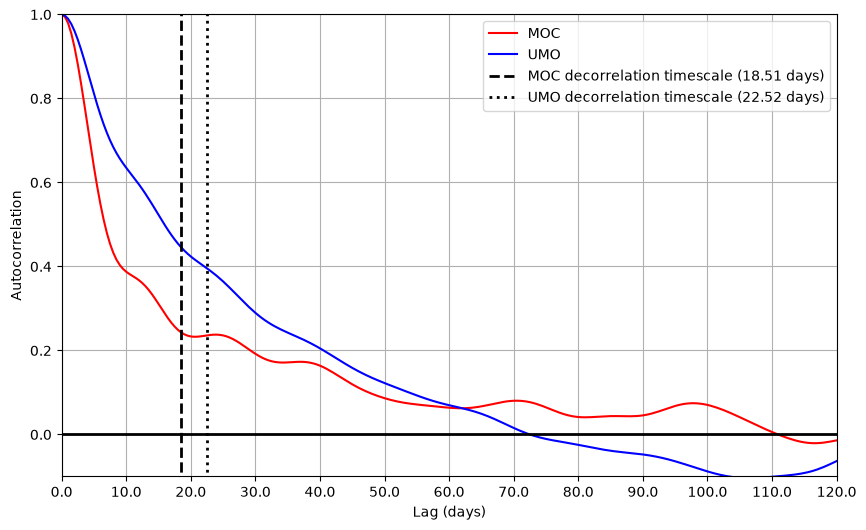

In [12]:
plt.figure(figsize=[10,6])
plt.plot(np.arange(len(ac_MOC_seasonal)),ac_MOC_seasonal, color = "red", label = "MOC")
plt.plot(np.arange(len(ac_UMO_seasonal)),ac_UMO_seasonal, color = "blue", label = "UMO")
plt.vlines(MOC_decorrelation_timescale*2,-1,2, lw = 2, ls = "--", color ="k", label = f"MOC decorrelation timescale ({MOC_decorrelation_timescale:.2f} days)")
plt.vlines(UMO_decorrelation_timescale*2,-1,2, lw = 2, ls = ":", color ="k", label = f"UMO decorrelation timescale ({UMO_decorrelation_timescale:.2f} days)")
plt.hlines(0, -1,1000, ls = "-", lw = 2, color = "k")
plt.xticks(np.arange(0,len(ac_MOC_seasonal),20),np.arange(0,len(ac_MOC_seasonal)/2,20/2))
plt.xlim(0,2*120)
plt.ylim(-0.1,1)
plt.ylabel("Autocorrelation")
plt.xlabel("Lag (days)")
plt.legend()
plt.grid()
plt.show()

In [13]:
MOC_N_eff = correlation.effective_dof(MOC_seasonal_detrended, 0.5)
UMO_N_eff = correlation.effective_dof(UMO_seasonal_detrended, 0.5)
print(f"Number of effective samples in the RAPID MOC timeseries {MOC_N_eff}")
print(f"Number of effective samples in the RAPID UMO timeseries {UMO_N_eff}")

no xarray type, possibly already detrended
no xarray type, possibly already detrended
Number of effective samples in the RAPID MOC timeseries 196
Number of effective samples in the RAPID UMO timeseries 161


In [14]:
predictor = np.arange(len(MOC))*0.5
MOC_trend_result = trends.trend_with_significance(predictor,MOC,dt = 0.5)
UMO_trend_result = trends.trend_with_significance(predictor,TRANS_UMO,dt = 0.5)

no xarray type, possibly already detrended
no xarray type, possibly already detrended


In [15]:
print(f"There is a {(100 * MOC_trend_result.p_eff):.2f} % chance that the measured decline of the MOC measured by the RAPID array is due to chaotic random chance.")
print("The MOC decline is not siginficant at 95%.")
print(f"There is a {(100 * UMO_trend_result.p_eff):.2f} % chance that the measured decline of the UMO measured by the RAPID array is due to chaotic random chance.")
print("The UMO decline is siginficant at 95%.")

There is a 8.09 % chance that the measured decline of the MOC measured by the RAPID array is due to chaotic random chance.
The MOC decline is not siginficant at 95%.
There is a 2.20 % chance that the measured decline of the UMO measured by the RAPID array is due to chaotic random chance.
The UMO decline is siginficant at 95%.
